<a href="https://colab.research.google.com/github/hernandez-figueroa/Metodos-Numericos-2/blob/main/Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
def romberg(f, a, b, n):
  R = np.zeros((n + 1, n + 1))
  h = b - a
  R[1, 1] = 0.5 * h * (f(a) + f(b))              # Trapecio simple

  for i in range(2, n + 1):
    suma = 0
    puntos = 2 ** (i - 2)
    # Evaluamos en los puntos medios del paso anterior
    for k in range(1, puntos + 1):
      suma += f(a + (k - 0.5) * h)

    R[i, 1] = 0.5 * R[i - 1, 1] + 0.5 * h * suma  # Trapecio compuesto

    # Extrapolación de Richardson
    for j in range(2, i + 1):
      R[i, j] = R[i, j - 1] + (R[i, j - 1] - R[i - 1, j - 1]) / (4 ** (j - 1) - 1)

    h = h / 2

  return R

In [25]:
import numpy as np
import matplotlib.pyplot as plt


In [28]:
# Datos
f2 = 0.51342
f3 = 0.36788
R31 = 0.43687
R33 = 0.43662

# Primera fila (h1 = 1)
h1 = 1
R11 = h1 / 2 * (f2 + f3)

# Despeje de f(2.5) a partir de R33 = (64*R31 - 20*R21 + R11) / 45
# y R21 = (R11 + f(2.5)) / 2
f25 = (64 * R31 - 9 * R11 - 45 * R33) / 10

print(f"R11 = {R11:.5f}")
print(f"f(2.5) = {f25:.5f}")

R11 = 0.44065
f(2.5) = 0.43459


In [29]:
T = np.zeros((4, 4))
T[1, 1] = R11
T[2, 1] = (R11 + h1 * f25) / 2
T[2, 2] = T[2, 1] + (T[2, 1] - T[1, 1]) / 3
T[3, 1] = R31
T[3, 2] = T[3, 1] + (T[3, 1] - T[2, 1]) / 3
T[3, 3] = T[3, 2] + (T[3, 2] - T[2, 2]) / 15

for i in range(1, 4):
    for j in range(1, i + 1):
        print(f"{T[i, j]:.6f}", end="  ")
    print()

print(f"\nR33 calculado = {T[3, 3]:.5f}   (dato: {R33:.5f})")


0.440650  
0.437621  0.436612  
0.436870  0.436619  0.436620  

R33 calculado = 0.43662   (dato: 0.43662)


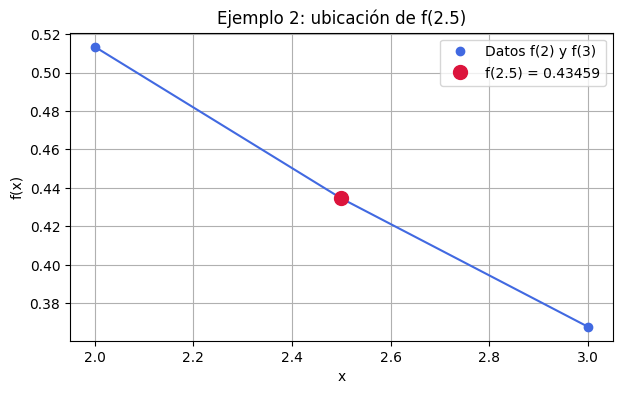

In [30]:
x = np.array([2, 2.5, 3])
y = np.array([f2, f25, f3])

plt.figure(figsize=(7, 4))
plt.plot(x, y, "-", color="royalblue")
plt.plot([2, 3], [f2, f3], "o", color="royalblue", label="Datos f(2) y f(3)")
plt.plot(2.5, f25, "o", color="crimson", markersize=10, label=f"f(2.5) = {f25:.5f}")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Ejemplo 2: ubicación de f(2.5)")
plt.grid(True)
plt.legend()
plt.show()